# Getting started with BI500 data in echopype

This notebook follows the same general workflow as the echopype getting-started example, adapted to the BI500 data model. BI500 differs from EK60/EK80 because a single acquisition is stored as a **set of companion files** rather than a single `.raw` file. In addition, each frequency/transceiver channel have its own companion-file set.
For one BI500 acquisition, all channel file sets can be kept in the same directory. `open_raw()` discovers the sets and returns:

- an `EchoData` object containing metadata and ancillary information;
- a calibrated `xarray.Dataset` (`ds_cal`) containing the BI500-generated `Sv` products, depth information, and single-target detections.

The BI500 `Sv` values are already nominally calibrated by the EK500/BI500 system, so `compute_Sv()` is not required.


## Imports


In [1]:
from pathlib import Path

import echopype as ep
import matplotlib.pyplot as plt
import numpy as np

## Locate the BI500 acquisition

A BI500 acquisition is represented by companion files ending in names such as:

- `-Data`
- `-Info`
- `-Ping`
- `-Vlog`
- `-Snap`
- `-Work`

The frequency and transceiver identifiers in the filename distinguish channels from the **same acquisition**. For example:

```text
...-F011990-T01-D20000921-T034142-Data
...-F037879-T02-D20000921-T034142-Data
...-F119048-T03-D20000921-T034142-Data
```

Different BI500 acquisitions should be opened separately. Their resulting xarray datasets can then be combined using standard xarray operations such as xr.concat or xr.combine_by_coords.

In [2]:
bi500_dir = Path("example_data") / "bi500_test_data"

if not bi500_dir.is_dir():
    raise FileNotFoundError(
        f"BI500 test-data directory not found: {bi500_dir}"
    )

bi500_dir

WindowsPath('example_data/bi500_test_data')

### Inspect the companion files


In [3]:
bi500_files = sorted(
    path.name
    for path in bi500_dir.iterdir()
    if path.is_file()
)

bi500_files


['N031-S445-S2000008-F011990-T01-D20000921-T034142-Data',
 'N031-S445-S2000008-F011990-T01-D20000921-T034142-Info',
 'N031-S445-S2000008-F011990-T01-D20000921-T034142-Ping',
 'N031-S445-S2000008-F011990-T01-D20000921-T034142-Snap',
 'N031-S445-S2000008-F011990-T01-D20000921-T034142-Vlog',
 'N031-S445-S2000008-F011990-T01-D20000921-T034142-Work',
 'N031-S445-S2000008-F037879-T02-D20000921-T034142-Data',
 'N031-S445-S2000008-F037879-T02-D20000921-T034142-Info',
 'N031-S445-S2000008-F037879-T02-D20000921-T034142-Ping',
 'N031-S445-S2000008-F037879-T02-D20000921-T034142-Snap',
 'N031-S445-S2000008-F037879-T02-D20000921-T034142-Vlog',
 'N031-S445-S2000008-F037879-T02-D20000921-T034142-Work',
 'N031-S445-S2000008-F119048-T03-D20000921-T034142-Data',
 'N031-S445-S2000008-F119048-T03-D20000921-T034142-Info',
 'N031-S445-S2000008-F119048-T03-D20000921-T034142-Ping',
 'N031-S445-S2000008-F119048-T03-D20000921-T034142-Snap',
 'N031-S445-S2000008-F119048-T03-D20000921-T034142-Vlog',
 'N031-S445-S2

The parser groups files that share the same acquisition identity but have different frequency/transceiver identifiers into separate channels. Each channel must contain the required `-Data`, `-Info`, and `-Ping` files.


In [4]:
required_suffixes = {"-Data", "-Info", "-Ping"}

available_suffixes = {
    suffix
    for path in bi500_dir.iterdir()
    if path.is_file()
    for suffix in required_suffixes
    if path.name.endswith(suffix)
}

missing_suffixes = required_suffixes - available_suffixes

if missing_suffixes:
    raise ValueError(
        f"Missing required BI500 file type(s): {sorted(missing_suffixes)}"
    )


## Open the BI500 acquisition

We use `open_raw()` to open the BI500 acquisition. All frequency/transceiver file sets belonging to that acquisition are parsed and assembled along the `channel` dimension.

In [5]:
echodata, ds_cal = ep.open_raw(
    raw_file=str(bi500_dir),
    sonar_model="BI500",
)

In [6]:
type(echodata), type(ds_cal)


(echopype.echodata.echodata.EchoData, xarray.core.dataset.Dataset)

## Inspect the `EchoData` object


In [7]:
echodata


<EchoData: standardized raw data from Internal Memory>
Top-level: contains metadata about the SONAR-netCDF4 file format.
├── Environment: contains information relevant to acoustic propagation through water.
├── Platform: contains information about the platform on which the sonar is installed.
├── Provenance: contains metadata about how the SONAR-netCDF4 version of the data were obtained.
├── Sonar: contains sonar system metadata and sonar beam groups.
│   └── Beam_group1: Contains BI500 channel, ping, and echogram geometry metadata.
└── Vendor_specific: contains vendor-specific information about the sonar and the data.

### Sonar and beam information

`Sonar/Beam_group1` contains the channel metadata, native ping timestamps, and BI500 metadata.

Because the different transceivers do not necessarily ping at exactly the same timestamps, the multi-channel object uses the union of the native `ping_time` values. Missing channel/time combinations are represented by `NaN`, following the same gridded-data approach used elsewhere in echopype.


In [8]:
beam = echodata["Sonar/Beam_group1"]
beam


<xarray.Dataset> Size: 635kB
Dimensions:                     (channel: 3, ping_time: 3960,
                                 ping_time_vlog: 1000, beam_group: 1)
Coordinates:
  * channel                     (channel) object 24B 'BI500-F11990-T01' ... '...
  * ping_time                   (ping_time) datetime64[ns] 32kB 2000-09-21T09...
  * ping_time_vlog              (ping_time_vlog) datetime64[ns] 8kB 2000-09-2...
  * beam_group                  (beam_group) <U11 44B 'Beam_group1'
Data variables:
    frequency_nominal           (channel) float64 24B 1.199e+04 ... 1.19e+05
    transceiver_channel_number  (channel) int64 24B 1 2 3
    echogram_type               (channel, ping_time) float64 95kB 0.0 ... 0.0
    echogram_type_vlog          (channel, ping_time_vlog) int64 24kB 0 0 ... 0 0
    pelagic_upper               (channel, ping_time) float64 95kB 0.0 ... 0.0
    pelagic_lower               (channel, ping_time) float64 95kB 500.0 ... 5...
    pelagic_upper_vlog          (channel, ping_time_vlog) float64 24kB 0.0 .....
    pelagic_lower_vlog          (channel, ping_time_vlog) float64 24kB 500.0 ...
    bottom_upper                (channel, ping_time) float64 95kB 10.0 ... 10.0
    bottom_lower                (channel, ping_time) float64 95kB -5.0 ... -5.0
    bottom_upper_vlog           (channel, ping_time_vlog) float64 24kB 10.0 ....
    bottom_lower_vlog           (channel, ping_time_vlog) float64 24kB -5.0 ....

In [9]:
print("channels:", beam.channel.values)
print("frequencies (Hz):", beam.frequency_nominal.values)
print("number of channels:", beam.sizes["channel"])
print("combined ping_time size:", beam.sizes["ping_time"])


channels: ['BI500-F11990-T01' 'BI500-F37879-T02' 'BI500-F119048-T03']
frequencies (Hz): [ 11990.  37879. 119048.]
number of channels: 3
combined ping_time size: 3960


The BI500 data are already calibrated, so the converted `EchoData` intentionally does **not** expose them as raw `backscatter_r` samples.


In [10]:
assert "backscatter_r" not in beam
assert "backscatter_r_bottom" not in beam


### Platform information


In [11]:
echodata["Platform"]


<xarray.Dataset> Size: 198kB
Dimensions:                   (ping_time: 3960, ping_time_vlog: 1000)
Coordinates:
  * ping_time                 (ping_time) datetime64[ns] 32kB 2000-09-21T09:2...
  * ping_time_vlog            (ping_time_vlog) datetime64[ns] 8kB 2000-09-21T...
Data variables:
    latitude                  (ping_time) float64 32kB 41.66 41.66 ... 41.61
    latitude_vlog             (ping_time_vlog) float64 8kB 41.66 41.66 ... 41.61
    longitude                 (ping_time) float64 32kB -68.58 -68.58 ... -68.57
    longitude_vlog            (ping_time_vlog) float64 8kB -68.58 ... -68.57
    bottom_depth              (ping_time) float64 32kB 169.2 169.2 ... 141.2
    bottom_depth_vlog         (ping_time_vlog) float64 8kB 169.2 169.2 ... 141.6
    vessel_log_distance       (ping_time) float64 32kB 2.127e+03 ... 2.132e+03
    vessel_log_distance_vlog  (ping_time_vlog) float64 8kB 2.127e+03 ... 2.13...
Attributes:
    platform_name:       
    platform_type:       
    platform_code_ICES:  445

## Inspect the calibrated dataset

`ds_cal` is the BI500 analogue of the calibrated dataset normally produced by `compute_Sv()`.

The principal gridded variables are:

- `Sv(channel, ping_time, range_sample)`
- `depth(channel, ping_time, range_sample)`
- `Sv_bottom(channel, ping_time, range_sample_bottom)`
- `depth_bottom(channel, ping_time, range_sample_bottom)`

For BI500, depth is reconstructed directly from the depth-referenced echogram bounds, so there is no need to call `add_depth()`.

In [12]:
ds_cal


<xarray.Dataset> Size: 95MB
Dimensions:                          (channel: 3, ping_time: 3960,
                                      range_sample: 500,
                                      range_sample_bottom: 150,
                                      single_target: 8724)
Coordinates:
  * channel                          (channel) <U17 204B 'BI500-F11990-T01' ....
  * ping_time                        (ping_time) datetime64[ns] 32kB 2000-09-...
  * range_sample                     (range_sample) int64 4kB 0 1 2 ... 498 499
  * range_sample_bottom              (range_sample_bottom) int64 1kB 0 1 ... 149
  * single_target                    (single_target) int64 70kB 0 1 ... 8723
Data variables: (12/17)
    Sv                               (channel, ping_time, range_sample) float32 24MB ...
    Sv_bottom                        (channel, ping_time, range_sample_bottom) float32 7MB ...
    frequency_nominal                (channel) float64 24B 1.199e+04 ... 1.19...
    depth                            (channel, ping_time, range_sample) float64 48MB ...
    depth_bottom                     (channel, ping_time, range_sample_bottom) float64 14MB ...
    pelagic_upper                    (channel, ping_time) float64 95kB 0.0 .....
    ...                               ...
    single_target_ping_time          (channel, single_target) datetime64[ns] 209kB ...
    single_target_depth              (channel, single_target) float64 209kB 5...
    single_target_alongship_angle    (channel, single_target) float64 209kB 0...
    single_target_athwartship_angle  (channel, single_target) float64 209kB 0...
    uncompensated_TS                 (channel, single_target) float64 209kB -...
    compensated_TS                   (channel, single_target) float64 209kB -...
Attributes:
    processing_function:  open_raw
    source_sonar_model:   BI500
    comment:              Automatically generated calibrated quantities by th...

In [13]:
for name in ["Sv", "depth", "Sv_bottom", "depth_bottom"]:
    print(name, ds_cal[name].dims, ds_cal[name].shape)

print()
print("channels:", ds_cal.channel.values)
print("frequencies (Hz):", ds_cal.frequency_nominal.values)


Sv ('channel', 'ping_time', 'range_sample') (3, 3960, 500)
depth ('channel', 'ping_time', 'range_sample') (3, 3960, 500)
Sv_bottom ('channel', 'ping_time', 'range_sample_bottom') (3, 3960, 150)
depth_bottom ('channel', 'ping_time', 'range_sample_bottom') (3, 3960, 150)

channels: ['BI500-F11990-T01' 'BI500-F37879-T02' 'BI500-F119048-T03']
frequencies (Hz): [ 11990.  37879. 119048.]


## Visualize the multi-frequency Sv data

### Plot each channel by native ping index

The channels are combined in ds_cal using their ping_time coordinates. For a compact view of each echogram, we plot the available data for each channel against a sequential ping index.


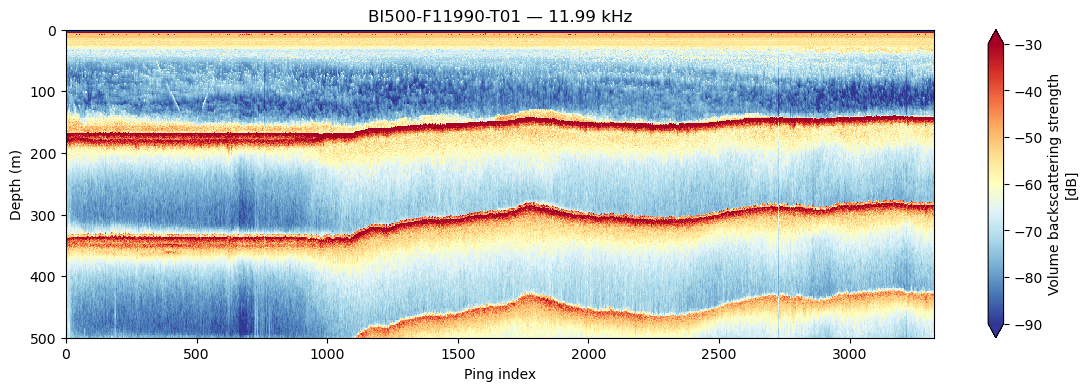

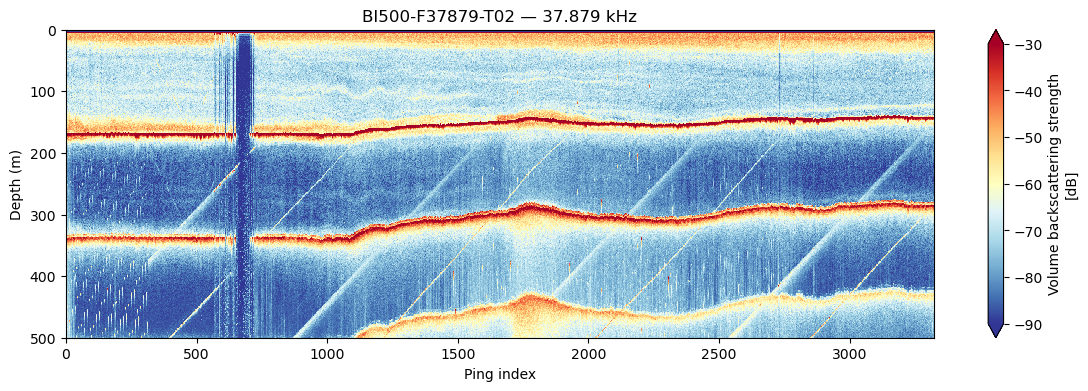

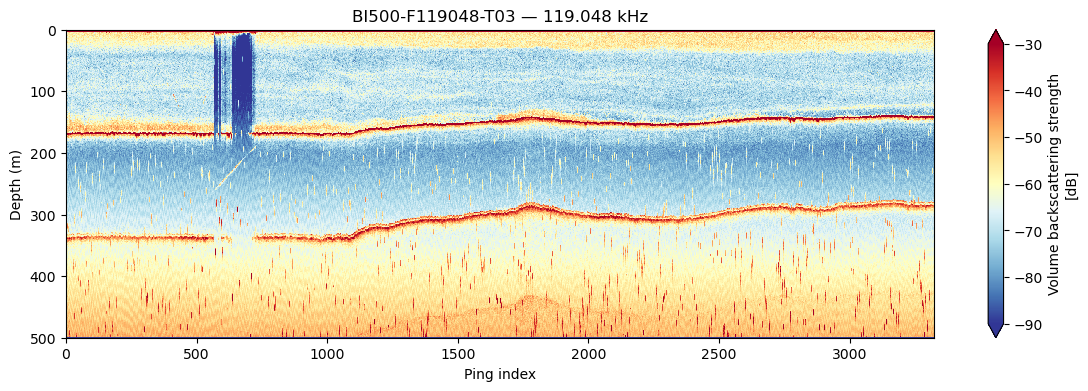

In [14]:
for channel in ds_cal.channel.values:
    ds_ch = ds_cal.sel(channel=channel)

    # Keep only pings that contain data for this channel
    valid_ping = np.isfinite(ds_ch["depth"]).any(dim="range_sample")
    ds_plot = ds_ch.isel(ping_time=valid_ping)

    sv = ds_plot["Sv"].assign_coords(
        depth=ds_plot["depth"],
        ping_index=("ping_time", np.arange(ds_plot.sizes["ping_time"])),
    )

    fig, ax = plt.subplots(figsize=(14, 4))

    sv.plot.pcolormesh(
        ax=ax,
        x="ping_index",
        y="depth",
        vmin=-90,
        vmax=-30,
        cmap="RdYlBu_r",
    )

    freq_khz = float(ds_plot["frequency_nominal"].values) / 1000

    ax.set_title(f"{channel} — {freq_khz:g} kHz")
    ax.set_xlabel("Ping index")
    ax.set_ylabel("Depth (m)")
    ax.invert_yaxis()

    plt.show()


### Plot each channel using its actual ping time

Plotting against `ping_time` preserves the true acquisition timing, so gaps between pings appear stretched in time.


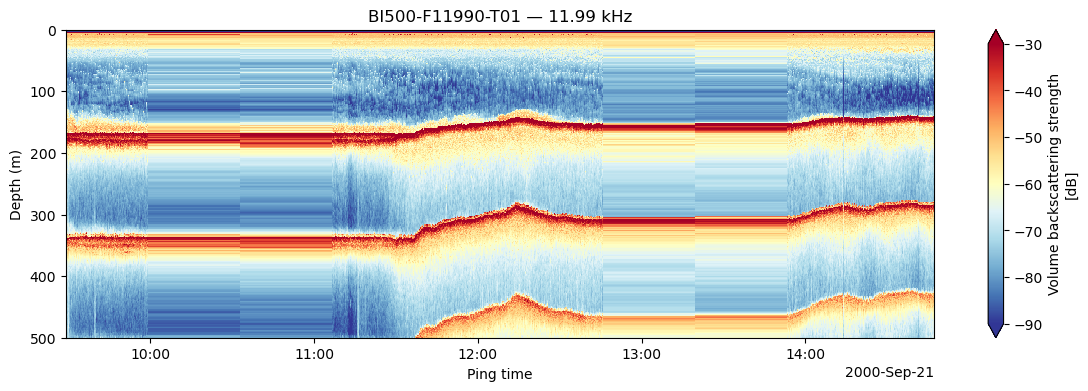

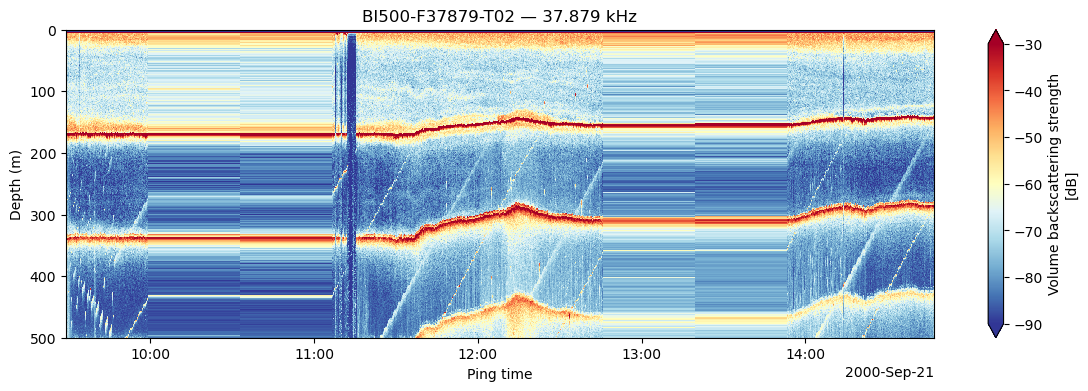

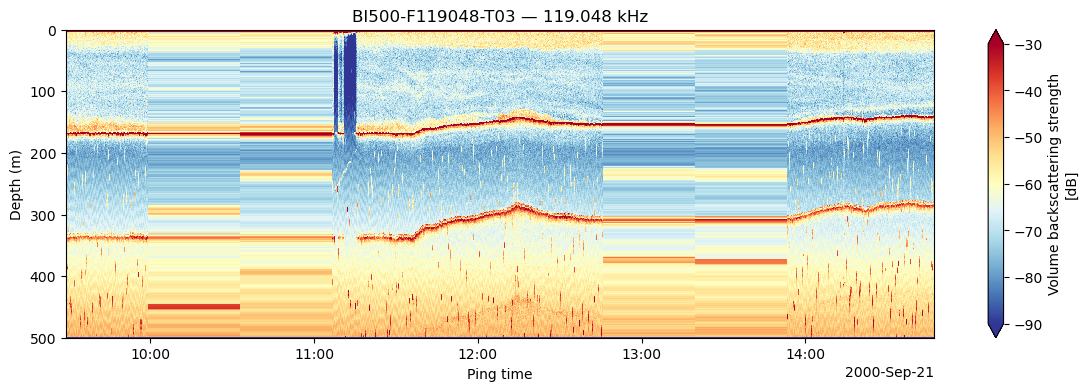

In [15]:
for channel in ds_cal.channel.values:
    ds_ch = ds_cal.sel(channel=channel)

    valid_ping = np.isfinite(ds_ch["depth"]).any(dim="range_sample")
    ds_plot = ds_ch.isel(ping_time=valid_ping)

    sv = ds_plot["Sv"].assign_coords(
        depth=ds_plot["depth"]
    )

    fig, ax = plt.subplots(figsize=(14, 4))

    sv.plot.pcolormesh(
        ax=ax,
        x="ping_time",
        y="depth",
        vmin=-90,
        vmax=-30,
        cmap="RdYlBu_r",
    )

    freq_khz = float(ds_plot["frequency_nominal"].values) / 1000

    ax.set_title(f"{channel} — {freq_khz:g} kHz")
    ax.set_xlabel("Ping time")
    ax.set_ylabel("Depth (m)")
    ax.invert_yaxis()

    plt.show()


## Single-target detections

BI500 also stores single-target detections, including depth, compensated and uncompensated target strength, ping time, and split-beam angles when available. We first inspect the target variables and their dimensions.

In [16]:
target_variables = [
    name
    for name, variable in ds_cal.data_vars.items()
    if "single_target" in variable.dims
]

ds_cal[target_variables]


<xarray.Dataset> Size: 2MB
Dimensions:                          (channel: 3, single_target: 8724)
Coordinates:
  * channel                          (channel) <U17 204B 'BI500-F11990-T01' ....
  * single_target                    (single_target) int64 70kB 0 1 ... 8723
Data variables:
    single_target_identifier         (channel, single_target) float64 209kB 0...
    ping_index                       (channel, single_target) float64 209kB 1...
    single_target_ping_time          (channel, single_target) datetime64[ns] 209kB ...
    single_target_depth              (channel, single_target) float64 209kB 5...
    single_target_alongship_angle    (channel, single_target) float64 209kB 0...
    single_target_athwartship_angle  (channel, single_target) float64 209kB 0...
    uncompensated_TS                 (channel, single_target) float64 209kB -...
    compensated_TS                   (channel, single_target) float64 209kB -...
Attributes:
    processing_function:  open_raw
    source_sonar_model:   BI500
    comment:              Automatically generated calibrated quantities by th...

### Overlay single targets on each channel

The code below selects the single-target detections associated with each channel and overlays them on the corresponding echogram.

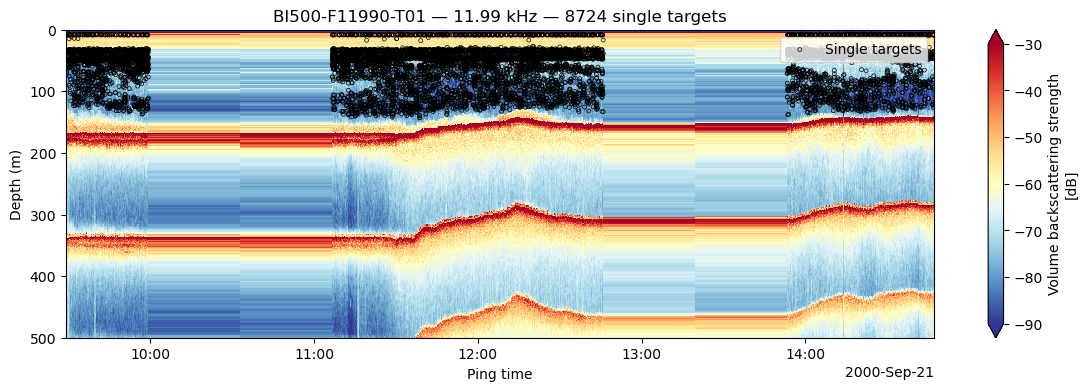

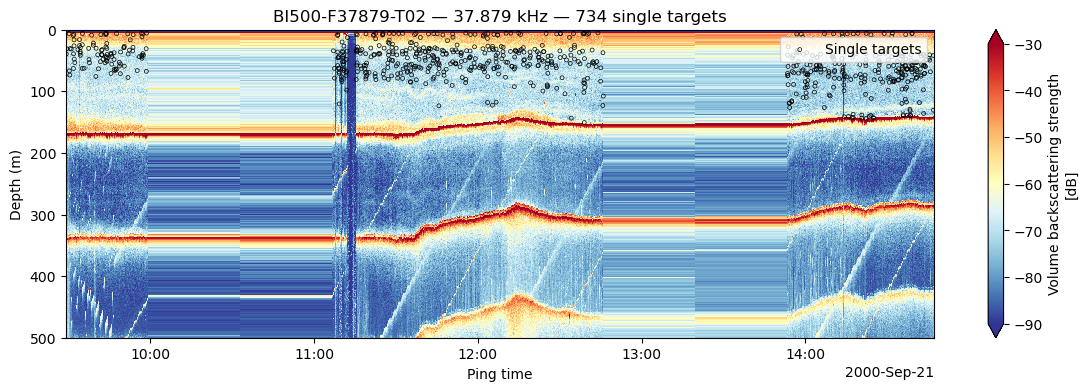

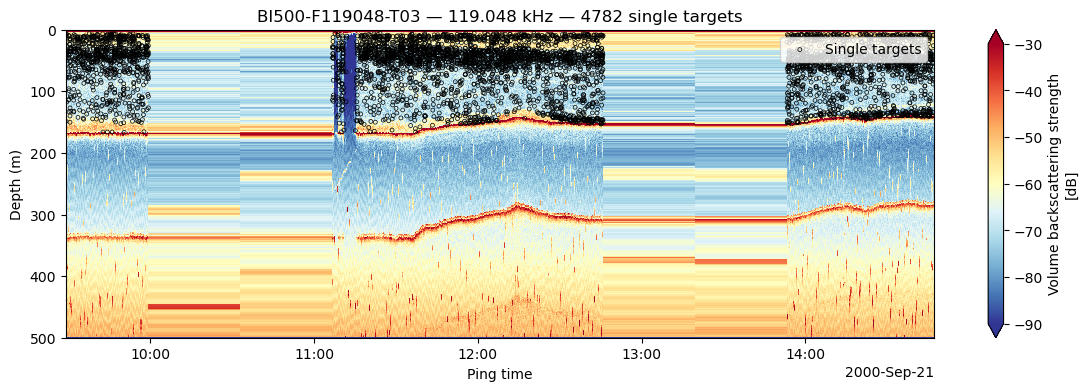

In [17]:
for channel in ds_cal.channel.values:
    ds_ch = ds_cal.sel(channel=channel)

    valid_ping = np.isfinite(ds_ch["depth"]).any(dim="range_sample")
    ds_plot = ds_ch.isel(ping_time=valid_ping)

    sv = ds_plot["Sv"].assign_coords(
        depth=ds_plot["depth"]
    )

    target_time = ds_ch["single_target_ping_time"].values
    target_depth = ds_ch["single_target_depth"].values

    valid_target = (
        ~np.isnat(target_time)
        & np.isfinite(target_depth)
    )

    fig, ax = plt.subplots(figsize=(14, 4))

    sv.plot.pcolormesh(
        ax=ax,
        x="ping_time",
        y="depth",
        vmin=-90,
        vmax=-30,
        cmap="RdYlBu_r",
    )

    ax.scatter(
        target_time[valid_target],
        target_depth[valid_target],
        s=8,
        facecolors="none",
        edgecolors="black",
        linewidths=0.5,
        label="Single targets",
    )

    freq_khz = float(ds_plot["frequency_nominal"].values) / 1000

    ax.set_title(
        f"{channel} — {freq_khz:g} kHz — "
        f"{valid_target.sum()} single targets"
    )
    ax.set_xlabel("Ping time")
    ax.set_ylabel("Depth (m)")
    ax.invert_yaxis()
    ax.legend(loc="upper right")

    plt.show()


## Compute mean volume backscattering strength (MVBS)

As in the general echopype getting-started workflow, we first check that `ping_time` is increasing, since reversed timestamps can cause problems with xarray operations.

In [18]:
from echopype.qc import exist_reversed_time, coerce_increasing_time

if exist_reversed_time(ds_cal, "ping_time"):
    coerce_increasing_time(ds_cal)

 The calibrated `Sv` data can then be placed on a common time/depth grid with `compute_MVBS()`. For BI500, the reconstructed `depth` variable is used directly as the vertical coordinate.

In [19]:
ds_MVBS = ep.commongrid.compute_MVBS(
    ds_cal,
    range_var="depth",
    range_bin="1m",
    ping_time_bin="5s",
    range_var_max="200m",
)

ds_MVBS


<xarray.Dataset> Size: 9MB
Dimensions:            (channel: 3, ping_time: 3818, depth: 201)
Coordinates:
  * channel            (channel) <U17 204B 'BI500-F119048-T03' ... 'BI500-F37...
  * ping_time          (ping_time) datetime64[ns] 31kB 2000-09-21T09:29:00 .....
  * depth              (depth) float64 2kB 0.0 1.0 2.0 3.0 ... 198.0 199.0 200.0
Data variables:
    Sv                 (channel, ping_time, depth) float32 9MB -235.2 ... -82.58
    frequency_nominal  (channel) float64 24B 1.19e+05 1.199e+04 3.788e+04
Attributes:
    processing_software_name:     echopype
    processing_software_version:  0.11.2.dev279+gfceebe878
    processing_time:              2026-08-08T16:41:34+00:00
    processing_function:          commongrid.compute_MVBS

### Plot MVBS for all frequencies


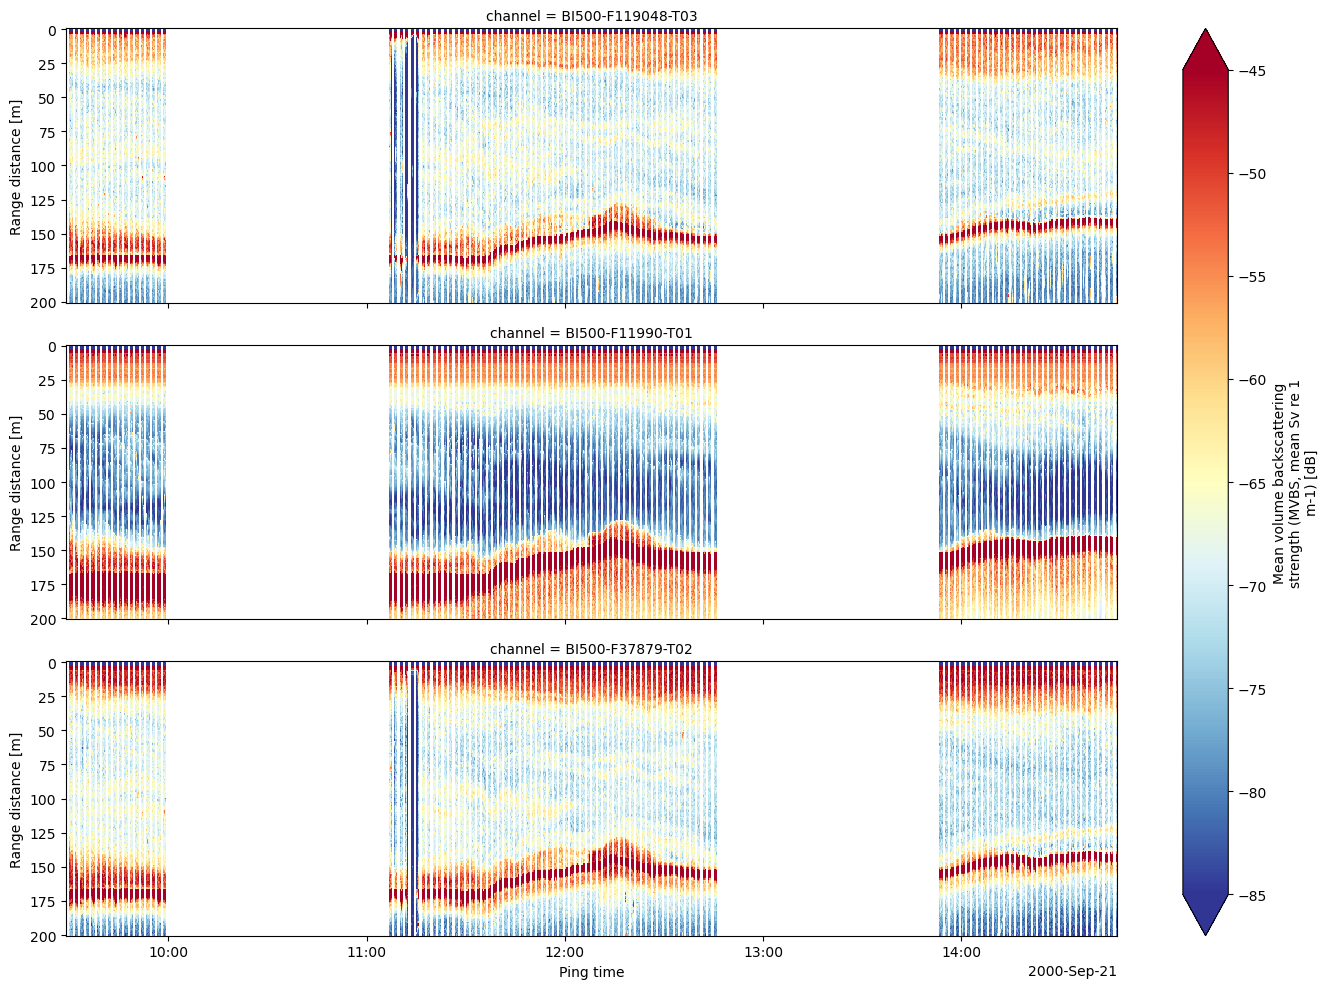

In [20]:
ds_MVBS["Sv"].plot(
    x="ping_time",
    row="channel",
    col_wrap=1,
    cmap="RdYlBu_r",
    yincrease=False,
    vmin=-85,
    vmax=-45,
    figsize=(14, 10),
)

plt.show()


It can also be convenient to index the gridded dataset by nominal frequency rather than the BI500 channel identifier.


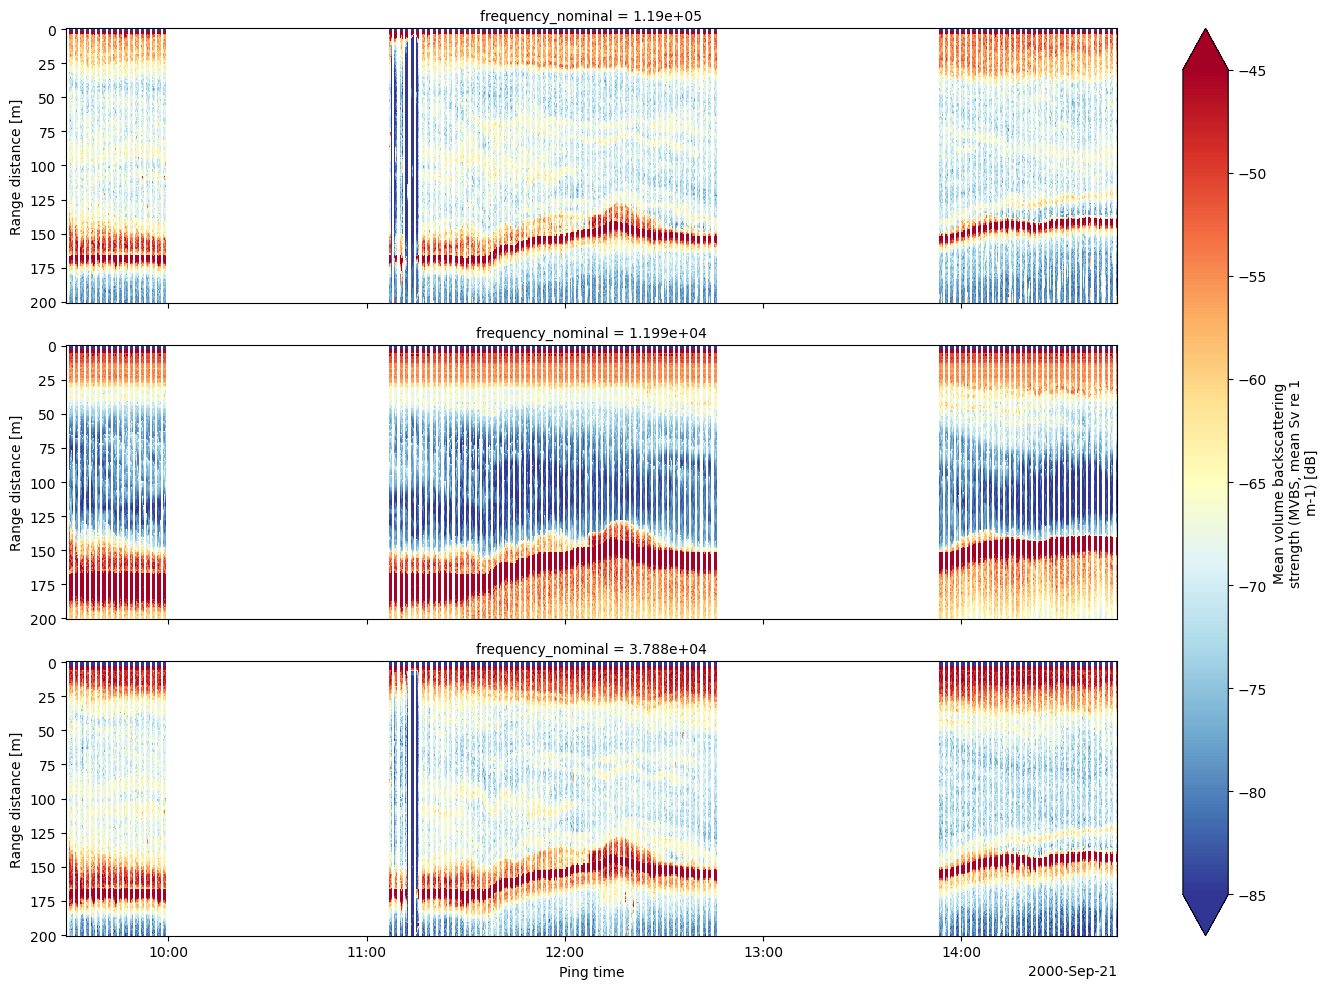

In [21]:
ds_MVBS_frequency = ds_MVBS.swap_dims(
    {"channel": "frequency_nominal"}
)

ds_MVBS_frequency["Sv"].plot(
    x="ping_time",
    row="frequency_nominal",
    col_wrap=1,
    cmap="RdYlBu_r",
    yincrease=False,
    vmin=-85,
    vmax=-45,
    figsize=(14, 10),
)

plt.show()


End of notebook.

In [22]:
import sys
from datetime import datetime, timezone

print("Notebook executed:", datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC"))
print("Python:", sys.version.split()[0])
print("echopype:", ep.__version__)
print("numpy:", np.__version__)

Notebook executed: 2026-08-08 16:41:48 UTC
Python: 3.12.13
echopype: 0.11.2.dev279+gfceebe878
numpy: 2.4.4
